In [1]:
# uncomment to dowload packages (need to do only once)
# using Pkg
# Pkg.add("BifurcationKit");Pkg.add("Plots");Pkg.add("SparseArrays");Pkg.add("DifferentialEquations")
#import Pkg; Pkg.add("NLsolve")
# import Pkg; Pkg.add("LaTeXStrings")

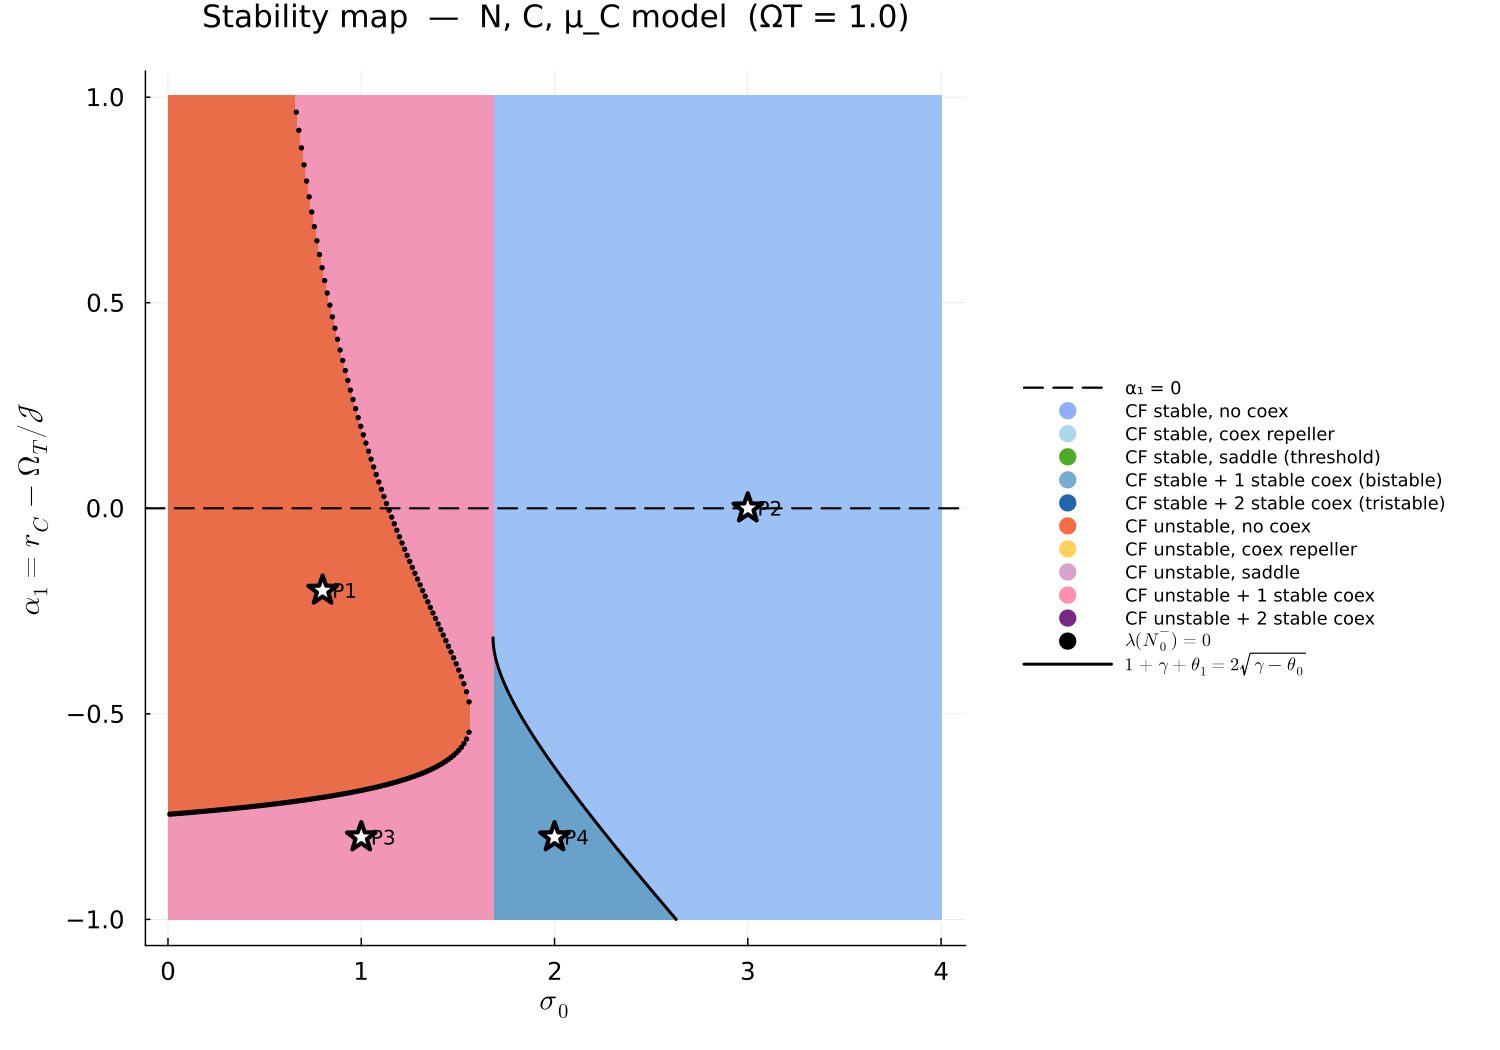

  0.123898 seconds (2.08 M allocations: 96.670 MiB, 7.52% gc time, 58.04% compilation time)


In [2]:
using LinearAlgebra, Plots, Printf, LaTeXStrings

# ─────────────────────────────────────────────────────────────
# 1.  Fixed parameters
# ─────────────────────────────────────────────────────────────
const r    = 0.08078290935711611
const δC   = 0.024386186139200513
const δN   = 0.01
const Ω    = 0.18381041120330566
const βr   = 0.021848896684677162
const βδ   = 0.18381041120330566
const σ1   = 0.8626645475366396
const 𝒥    = 1.0
const 𝒦    = 1.0
const ρmax  = 𝒦
const ΩC   = Ω

const ROOT_DEDUP_TOL = 1e-6
const EIG_TOL        = 1e-10

# ─────────────────────────────────────────────────────────────
# 2.  ODE & Jacobian
# ─────────────────────────────────────────────────────────────
function ode!(du, u, σ0, rC, ΩT)
    N, C, μC = u
    Cs = max(C, 1e-12)
    L  = 𝒥
    du[1] = r*N*(1 - N/ρmax) - δN*(1 - μC)*Cs*N
    du[2] = σ0 + σ1*N + rC*Cs*N - βr*Cs*μC*N - βδ*μC*Cs - δC*Cs
    du[3] = (ΩT*N/L + Ω/L)*(1 - μC) - βr*μC*N*(1 - μC) - βδ*μC*(1 - μC) -
            (μC/Cs)*(σ0 + σ1*N)
end

function jacobian(u, σ0, rC, ΩT)
    N, C, μC = u
    Cs = max(C, 1e-12)
    L  = 𝒥
    J  = zeros(3, 3)
    J[1,1] = r - 2*r*N/ρmax - δN*(1 - μC)*Cs
    J[1,2] = -δN*(1 - μC)*N
    J[1,3] =  δN*N*Cs
    J[2,1] = σ1 + rC*Cs - βr*Cs*μC
    J[2,2] = rC*N - βr*μC*N - βδ*μC - δC
    J[2,3] = -βr*Cs*N - βδ*Cs
    J[3,1] = (ΩT/L)*(1 - μC) - βr*μC*(1 - μC) - (μC/Cs)*σ1
    J[3,2] =  (μC/Cs^2)*(σ0 + σ1*N)
    J[3,3] = -ΩT*N/L - Ω/L - (βr*N + βδ)*(1 - 2*μC) - (σ0 + σ1*N)/Cs
    return J
end

# ─────────────────────────────────────────────────────────────
# 3.  Cancer-free SS & stability
# ─────────────────────────────────────────────────────────────
function cancer_free_SS(σ0)
    ΩoJ = Ω / 𝒥
    μC0 = ΩoJ / (ΩoJ + βδ + δC)
    C0  = σ0 / (βδ * μC0 + δC)
    return [0.0, C0, μC0]
end

function cf_stability(σ0)
    _, C0, μC0 = cancer_free_SS(σ0)
    return r - δN*(1 - μC0)*C0
end

# ─────────────────────────────────────────────────────────────
# 4.  Coexistence roots
#
#     A·N² + B·N + C_coef = 0,     A = rC − ΩT/𝒥
# ─────────────────────────────────────────────────────────────
function coex_quadratic_coeffs(σ0, rC, ΩT)
    α1     = rC - ΩT/𝒥
    A      = α1
    B      = (ΩT * 𝒦)/𝒥 - rC*𝒦 - ΩC/𝒥 - δC - δN*σ1/r
    C_coef = (ΩC * 𝒦)/𝒥 + δC*𝒦 - δN*σ0/r
    return A, B, C_coef
end

function coex_C_muC(N, σ0, rC, ΩT)
    ΩoJ  = Ω/𝒥
    ΩToJ = ΩT/𝒥
    denom_mu = ΩToJ*N + ΩoJ + βr*N + βδ + δC - rC*N

    abs(denom_mu) < 1e-10 && return -1.0, -1.0

    μC = (ΩToJ*N + ΩoJ) / denom_mu
    (μC <= 0.0 || μC >= 1.0) && return -1.0, -1.0

    denom_C = βr*N*μC + βδ*μC + δC - rC*N
    (abs(denom_C) < 1e-12 || denom_C < 0) && return -1.0, -1.0

    C = (σ0 + σ1*N) / denom_C
    return C, μC
end

"""
    coex_roots(σ0, rC, ΩT) -> Vector{NTuple{3,Float64}}
"""
function coex_roots(σ0, rC, ΩT)
    A, B, C_coef = coex_quadratic_coeffs(σ0, rC, ΩT)
    N_candidates = Float64[]

    if abs(A) < 1e-12
        # Degenerate (linear) case: A ≈ 0
        if abs(B) >= 1e-12
            N_cand = -C_coef / B
            N_cand > 0 && push!(N_candidates, N_cand)
        end
    else
        disc = B^2 - 4*A*C_coef
        if disc >= 0
            sqrt_disc = sqrt(disc)
            for s in (+1, -1)
                N_cand = (-B + s*sqrt_disc) / (2*A)
                N_cand > 1e-8 && N_cand < ρmax && push!(N_candidates, N_cand)
            end
            
            if length(N_candidates) == 2 &&
               abs(N_candidates[1] - N_candidates[2]) < ROOT_DEDUP_TOL
                N_candidates = [N_candidates[1]]
            end
        end
    end

    roots = NTuple{3,Float64}[]
    for N_cand in N_candidates
        C_cand, μC_cand = coex_C_muC(N_cand, σ0, rC, ΩT)
        (C_cand > 0 && 0 < μC_cand < 1) || continue
        push!(roots, (N_cand, C_cand, μC_cand))
    end
    return roots
end

# ─────────────────────────────────────────────────────────────
# 5.  Classify & encode  — minimal scheme
# ─────────────────────────────────────────────────────────────
function coex_stability_type(λs)
    re    = real.(λs)
    n_neg = count(x -> x < -EIG_TOL, re)
    n_pos = count(x -> x >  EIG_TOL, re)
    if n_neg == 3
        return :stable
    elseif n_neg == 2 && n_pos == 1
        return :saddle_2s1u
    elseif n_neg == 1 && n_pos == 2
        return :saddle_1s2u
    else
        return :unstable
    end
end

function classify_point(σ0, α1, ΩT)
    rC        = α1 + ΩT/𝒥
    cf_stable = cf_stability(σ0) < 0
    roots     = coex_roots(σ0, rC, ΩT)   # Vector of (N, C, μC)

    n_stable_coex   = 0
    n_saddle_coex   = 0
    n_unstable_coex = 0

    for (N_, C_, μC_) in roots
        λs   = eigvals(jacobian([N_, C_, μC_], σ0, rC, ΩT))
        type = coex_stability_type(λs)
        if type == :stable
            n_stable_coex += 1
        elseif type ∈ (:saddle_2s1u, :saddle_1s2u)
            n_saddle_coex += 1
        else
            n_unstable_coex += 1
        end
    end

    has_coex        = !isempty(roots)
    has_stable_coex = n_stable_coex > 0
    has_saddle      = n_saddle_coex > 0

    if cf_stable
        !has_coex                                    ? 1 :
        has_coex && !has_stable_coex && !has_saddle  ? 2 :   # coex but pure repeller
        has_saddle && !has_stable_coex               ? 3 :   # CF stable + saddle only (threshold)
        n_stable_coex == 1                           ? 4 :   # CF stable + 1 stable coex (bistable)
                                                        5     # CF stable + 2 stable coex (tristable)
    else
        !has_coex                                    ? 6 :
        has_coex && !has_stable_coex && !has_saddle  ? 7 :
        has_saddle && !has_stable_coex               ? 8 :
        n_stable_coex == 1                           ? 9 :
                                                        10
    end
end

# ─────────────────────────────────────────────────────────────
# 6.  Grid sweep
# ─────────────────────────────────────────────────────────────
const ΩT_fixed = 1.0

n_σ, n_α = 300, 300
σ0_vals  = LinRange(0.01, 4, n_σ)
α1_vals  = LinRange(-1, 1, n_α)

map_labels = zeros(Int, n_σ, n_α)
@time for (i, σ0) in enumerate(σ0_vals)
    for (j, α1) in enumerate(α1_vals)
        map_labels[i, j] = classify_point(σ0, α1, ΩT_fixed)
    end
end
# ─────────────────────────────────────────────────────────────
# 6.5  λ(N₀⁻) = 0  boundary curve
# ─────────────────────────────────────────────────────────────

function N0_minus(σ0, rC, ΩT)
    A, B, C_coef = coex_quadratic_coeffs(σ0, rC, ΩT)
    abs(A) < 1e-12 && return NaN
    disc = B^2 - 4*A*C_coef
    disc < 0 && return NaN
    return (-B - sqrt(disc)) / (2*A)
end

function λ_N0minus(σ0, α1, ΩT)
    rC  = α1 + ΩT/𝒥
    N0m = N0_minus(σ0, rC, ΩT)
    isnan(N0m) && return NaN
    return N0m*(rC - βr) - βδ - δC
end


function bisect(f, a, b; tol=1e-10, maxiter=300)
    fa, fb = f(a), f(b)
    (isnan(fa) || isnan(fb) || sign(fa) == sign(fb)) && return NaN
    for _ in 1:maxiter
        m  = 0.5*(a+b)
        fm = f(m)
        isnan(fm) && return NaN
        (abs(fm) < tol || (b-a) < tol) && return m
        sign(fm) == sign(fa) ? ((a, fa) = (m, fm)) : (b = m)
    end
    return 0.5*(a+b)
end

function λ_boundary_curve(σ0_vals, ΩT; n_scan=4000, α1_bracket=(-1.0, 1.0))
    σ_out, α_out = Float64[], Float64[]
    αs = collect(range(α1_bracket[1], α1_bracket[2], length=n_scan))
    for σ0 in σ0_vals
        f    = α1 -> λ_N0minus(σ0, α1, ΩT)
        vals = f.(αs)
        for i in 1:length(αs)-1
            v1, v2 = vals[i], vals[i+1]
            (isnan(v1) || isnan(v2)) && continue
            if sign(v1) != sign(v2)
                r = bisect(f, αs[i], αs[i+1])
                !isnan(r) && (push!(σ_out, σ0); push!(α_out, r))
            end
        end
    end
    return σ_out, α_out
end

σ_bnd, α_bnd = λ_boundary_curve(collect(σ0_vals), ΩT_fixed;
                                 α1_bracket = (minimum(α1_vals), maximum(α1_vals)))



# ─────────────────────────────────────────────────────────────
# 6.6  Fold  curve: b² = 4c, i.e. 1+γ+θ1 = 2√(γ-θ0)
#
#  Restricted to α1 < 0, 1+γ+θ1 > 0, C_coef < 0 
# ─────────────────────────────────────────────────────────────

const α2_fixed = δC + Ω   # = δC + ΩC/𝒥, fixed (doesn't depend on α1 or σ0)

function fold_σ0(α1)
    α1 >= 0 && return NaN
    γ  = α2_fixed / α1
    θ1 = δN*σ1 / (r*α1)
    S  = 1 + γ + θ1
    S <= 0 && return NaN                      
    θ0 = γ - (S/2)^2
    σ0 = r*α1*θ0 / δN
    return σ0
end

function fold_curve(α1_vals, ΩT; σ0_domain=(0.0, 4.0))
    σ_out, α_out = Float64[], Float64[]
    for α1 in α1_vals
        α1 >= 0 && continue
        σ0 = fold_σ0(α1)
        (isnan(σ0) || σ0 <= σ0_domain[1] || σ0 >= σ0_domain[2]) && continue

        
        rC = α1 + ΩT/𝒥
        A, B, C_coef = coex_quadratic_coeffs(σ0, rC, ΩT)
        (C_coef >= 0) && continue             
        disc = B^2 - 4*A*C_coef
        abs(disc) > 1e-6*max(1.0, B^2) && continue   # sanity: should be ≈0

        push!(σ_out, σ0); push!(α_out, α1)
    end
    return σ_out, α_out
end

σ_fold, α_fold = fold_curve(collect(range(minimum(α1_vals), -1e-6, length=4000)),
                             ΩT_fixed)
# ─────────────────────────────────────────────────────────────
# 7.  Plot
# ─────────────────────────────────────────────────────────────
palette_colours = [
    colorant"#90aefe",   # 1  CF stable, no coex
    colorant"#ABD9E9",   # 2  CF stable, coex pure repeller
    colorant"#4DAC26",   # 3  CF stable, saddle only (threshold)
    colorant"#74ADD1",   # 4  CF stable + 1 stable coex (bistable)
    colorant"#2166AC",   # 5  CF stable + 2 stable coex (tristable)
    colorant"#F46D43",   # 6  CF unstable, no coex
    colorant"#fed25d",   # 7  CF unstable, coex pure repeller
    colorant"#D9A0C8",   # 8  CF unstable, saddle only
    colorant"#fe90ae",   # 9  CF unstable + 1 stable coex
    colorant"#762A83",   # 10 CF unstable + 2 stable coex
]

label_names = [
    "CF stable, no coex",
    "CF stable, coex repeller",
    "CF stable, saddle (threshold)",
    "CF stable + 1 stable coex (bistable)",
    "CF stable + 2 stable coex (tristable)",
    "CF unstable, no coex",
    "CF unstable, coex repeller",
    "CF unstable, saddle",
    "CF unstable + 1 stable coex",
    "CF unstable + 2 stable coex",
]

hm = heatmap(
    collect(σ0_vals), collect(α1_vals), map_labels',
    c             = palette_colours,
    clims         = (0.5, 10.5),
    colorbar      = false,
    xlabel        = L"\sigma_0",
    ylabel        = L"\alpha_1 = r_C - \Omega_T / \mathcal{J}",
    title         = "Stability map  —  N, C, μ_C model  (ΩT = $ΩT_fixed)",
    size          = (1000, 700),
    dpi           = 150,
    guidefontsize = 13,
    tickfontsize  = 11,
    titlefontsize = 14,
    margin        = 5Plots.mm,
)

hline!([0.0], lw=1.5, ls=:dash, c=:black, label="α₁ = 0")

for (col, lbl) in zip(palette_colours, label_names)
    scatter!([NaN], [NaN], mc=col, ms=8, msw=0, label=lbl)
end

plot!(
    legend         = :outerright,
    legendfontsize = 8,
    fg_legend      = :transparent,
    bg_legend      = :white,
)

sim_points = [
    #   label   σ0    rC    ΩT_val
    ("P1",  0.8,  0.8,  1.0),
    ("P2",  3.0,  1.0,  1.0),
    ("P3",  1.0,  0.2,  1.0),
    ("P4",  2.0,  0.2,  1.0),
]

for (lbl, σ0, rC, ΩT_val) in sim_points
    α1 = rC - ΩT_val/𝒥
    scatter!([σ0], [α1],
             ms=10, msw=2, mc=:white, msc=:black,
             markershape=:star5,
             label="")
    annotate!(σ0 + 0.06, α1, text(lbl, :left, 9, :black))
end

scatter!(σ_bnd, α_bnd,
         ms = 2, msw = 0, mc = :black,
         label = L"\lambda(N_0^{-})=0")

         # sort for a clean line rather than scattered points
ord = sortperm(σ_fold)
plot!(σ_fold[ord], α_fold[ord],
      lw = 2, lc = :black, ls = :solid,
      label = L"1+\gamma+\theta_1=2\sqrt{\gamma-\theta_0}")
display(hm)